# K-Means

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans as SklearnKMeans

from models.k_means_2 import KMeans

from utils.plots import plot_decision_boundary

## Dataset

In [ ]:
# Generation
X, y_true = make_blobs(
    n_samples=1000,
    centers=4,
    cluster_std=1.2,
    random_state=42,
)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

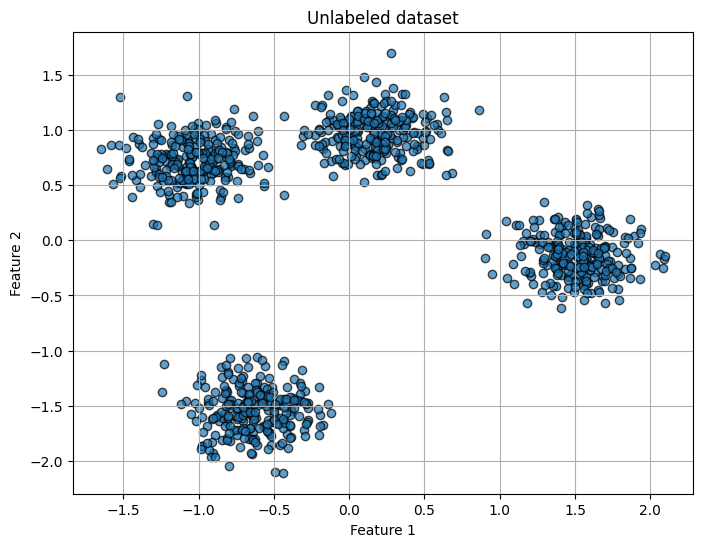

In [4]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    alpha=0.7,
    edgecolor="k",
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Unlabeled dataset")
plt.grid(True)

plt.show()

## Fitting

In [9]:
# Scratch model
scratch_kmeans = KMeans(
    K=4,
    max_iters=100,
    tol=1e-4,
    random_state=42,
)

scratch_labels = scratch_kmeans.fit_predict(X_scaled)

# Sklearn model
sklearn_kmeans = SklearnKMeans(
    n_clusters=4,
    random_state=42,
    n_init=10,
)

sklearn_labels = sklearn_kmeans.fit_predict(X_scaled)

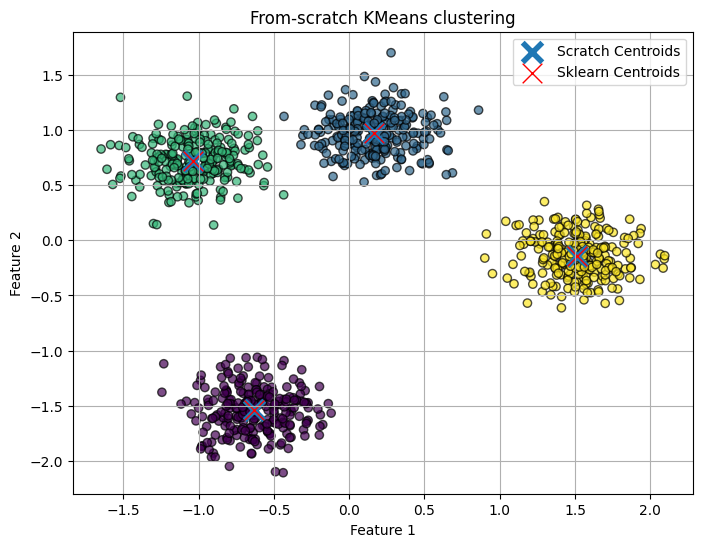

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=scratch_labels,
    alpha=0.7,
    edgecolor="k",
)

plt.scatter(
    scratch_kmeans.centroids[:, 0],
    scratch_kmeans.centroids[:, 1],
    marker="x",
    s=200,
    linewidths=4,
    label="Scratch Centroids",
)

plt.scatter(
    sklearn_kmeans.cluster_centers_[:, 0],
    sklearn_kmeans.cluster_centers_[:, 1],
    marker="x",
    s=200,
    linewidths=1,
    label="Sklearn Centroids",
    c='red'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("From-scratch KMeans clustering")
plt.legend()
plt.grid(True)

plt.show()

### Inertia History

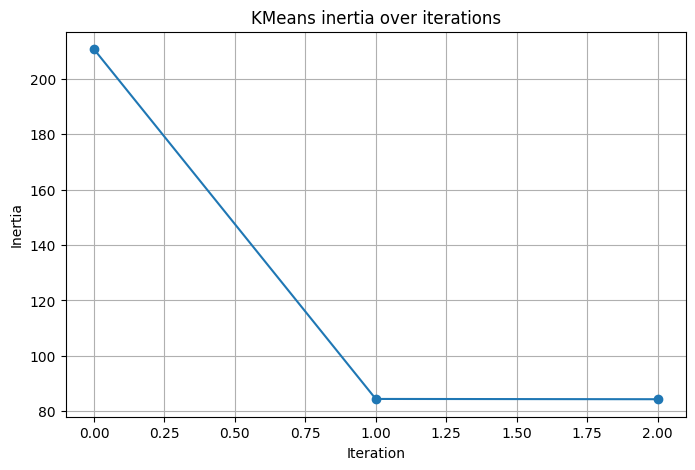

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(scratch_kmeans.inertia_history, marker="o")

plt.xlabel("Iteration")
plt.ylabel("Inertia")
plt.title("KMeans inertia over iterations")
plt.grid(True)

plt.show()

## Hyperparameter Sweeps

### Number of Clusters `K`
We can see that going from `K=1` to `K=4` gives a very big improvement each time, while above `K=4` there are only minor improvements. 

This suggests that `K=4` is the optimal number of clusters, which is coherent with the fact that we created the dataset with 4 centers.

With `K=1`, all the points are forced into a single cluster, so inertia is huge. As we increase `K`, there are more centroids, so the average distance to the nearest centroid is smaller, and inertia diminishes. By definition, inertia will always decrease as `K` increases, until it becomes 0 when the number of clusters equals the number of points in the dataset, however basically no additional information is being obtained, so choosing a `K` above the optimal one is not indicated. 

In [28]:
k_values = list(range(1, 11))

rows = []

for k in k_values:
    model = KMeans(
        K=k,
        max_iters=100,
        tol=1e-4,
        random_state=42,
    )

    scratch_labels = model.fit_predict(X_scaled)

    rows.append({
        "K": k,
        "final_inertia": model.inertia_history[-1],
    })

k_sweep_df = pd.DataFrame(rows)

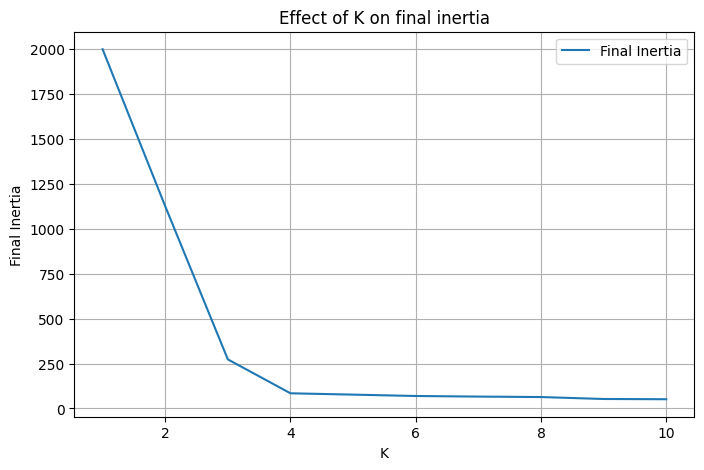

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(k_sweep_df["K"], k_sweep_df["final_inertia"], label="Final Inertia")

plt.xlabel("K")
plt.ylabel("Final Inertia")
plt.title("Effect of K on final inertia")
plt.legend()
plt.grid(True)

plt.show()